# Predict Customer Churn — Kaggle Playground Series S6E3

**Goal:** Predict the likelihood of customer churn  
**Metric:** ROC-AUC  
**Deadline:** March 31, 2026

**Strategy:**
1. EDA — understand the data
2. Baseline model — quick first submission
3. Feature engineering — improve score
4. Ensembling — final boost

## 1. Setup & Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')
import os

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('visuals', exist_ok=True)

train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
sample_sub = pd.read_csv('data/sample_submission.csv')

# Convert Churn to numeric
train['Churn'] = (train['Churn'] == 'Yes').astype(int)

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")
print(f"\nTarget distribution:")
print(train['Churn'].value_counts())
print(f"\nChurn rate: {train['Churn'].mean():.2%}")
print(f"\nColumns:")
print(train.columns.tolist())

Train: (594194, 21)
Test:  (254655, 20)

Target distribution:
Churn
0    460377
1    133817
Name: count, dtype: int64

Churn rate: 22.52%

Columns:
['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


### Dataset Overview

- **Train: 594,194 rows | 21 columns**
- **Test: 254,655 rows | 20 columns**
- **Churn rate: 22.52%** — moderately imbalanced, no oversampling needed
- **Target:** Churn (Yes/No → 1/0)
- **Features:** demographic (gender, SeniorCitizen), 
  service usage (PhoneService, InternetService etc.), 
  account info (tenure, Contract, MonthlyCharges)

## 2. Exploratory Data Analysis

In [7]:
# Check data types and missing values
print("=== Data Types & Missing Values ===")
info = pd.DataFrame({
    'dtype': train.dtypes,
    'missing': train.isnull().sum(),
    'missing_%': (train.isnull().sum() / len(train) * 100).round(2),
    'unique': train.nunique()
})
print(info.to_string())

# Separate numeric and categorical columns
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric columns: {numeric_cols}")
print(f"\nCategorical columns: {categorical_cols}")

=== Data Types & Missing Values ===
                    dtype  missing  missing_%  unique
id                  int64        0        0.0  594194
gender             object        0        0.0       2
SeniorCitizen       int64        0        0.0       2
Partner            object        0        0.0       2
Dependents         object        0        0.0       2
tenure              int64        0        0.0      72
PhoneService       object        0        0.0       2
MultipleLines      object        0        0.0       3
InternetService    object        0        0.0       3
OnlineSecurity     object        0        0.0       3
OnlineBackup       object        0        0.0       3
DeviceProtection   object        0        0.0       3
TechSupport        object        0        0.0       3
StreamingTV        object        0        0.0       3
StreamingMovies    object        0        0.0       3
Contract           object        0        0.0       3
PaperlessBilling   object        0        0.0 

### Observations

- **No missing values** — clean dataset, no imputation needed
- **15 categorical columns, 4 numeric columns**
- Some categorical columns have 3 unique values instead of 2
- **tenure** has 72 unique values — months with the company
- **TotalCharges** has 31,910 unique values — essentially continuous

### 2.1 Churn Analysis

We examine how churn rate varies across key features:
- **Contract type** — does contract length affect churn?
- **Tenure** — do newer customers churn more?
- **Monthly charges** — does price drive churn?
- **Internet service** — does service type affect churn?

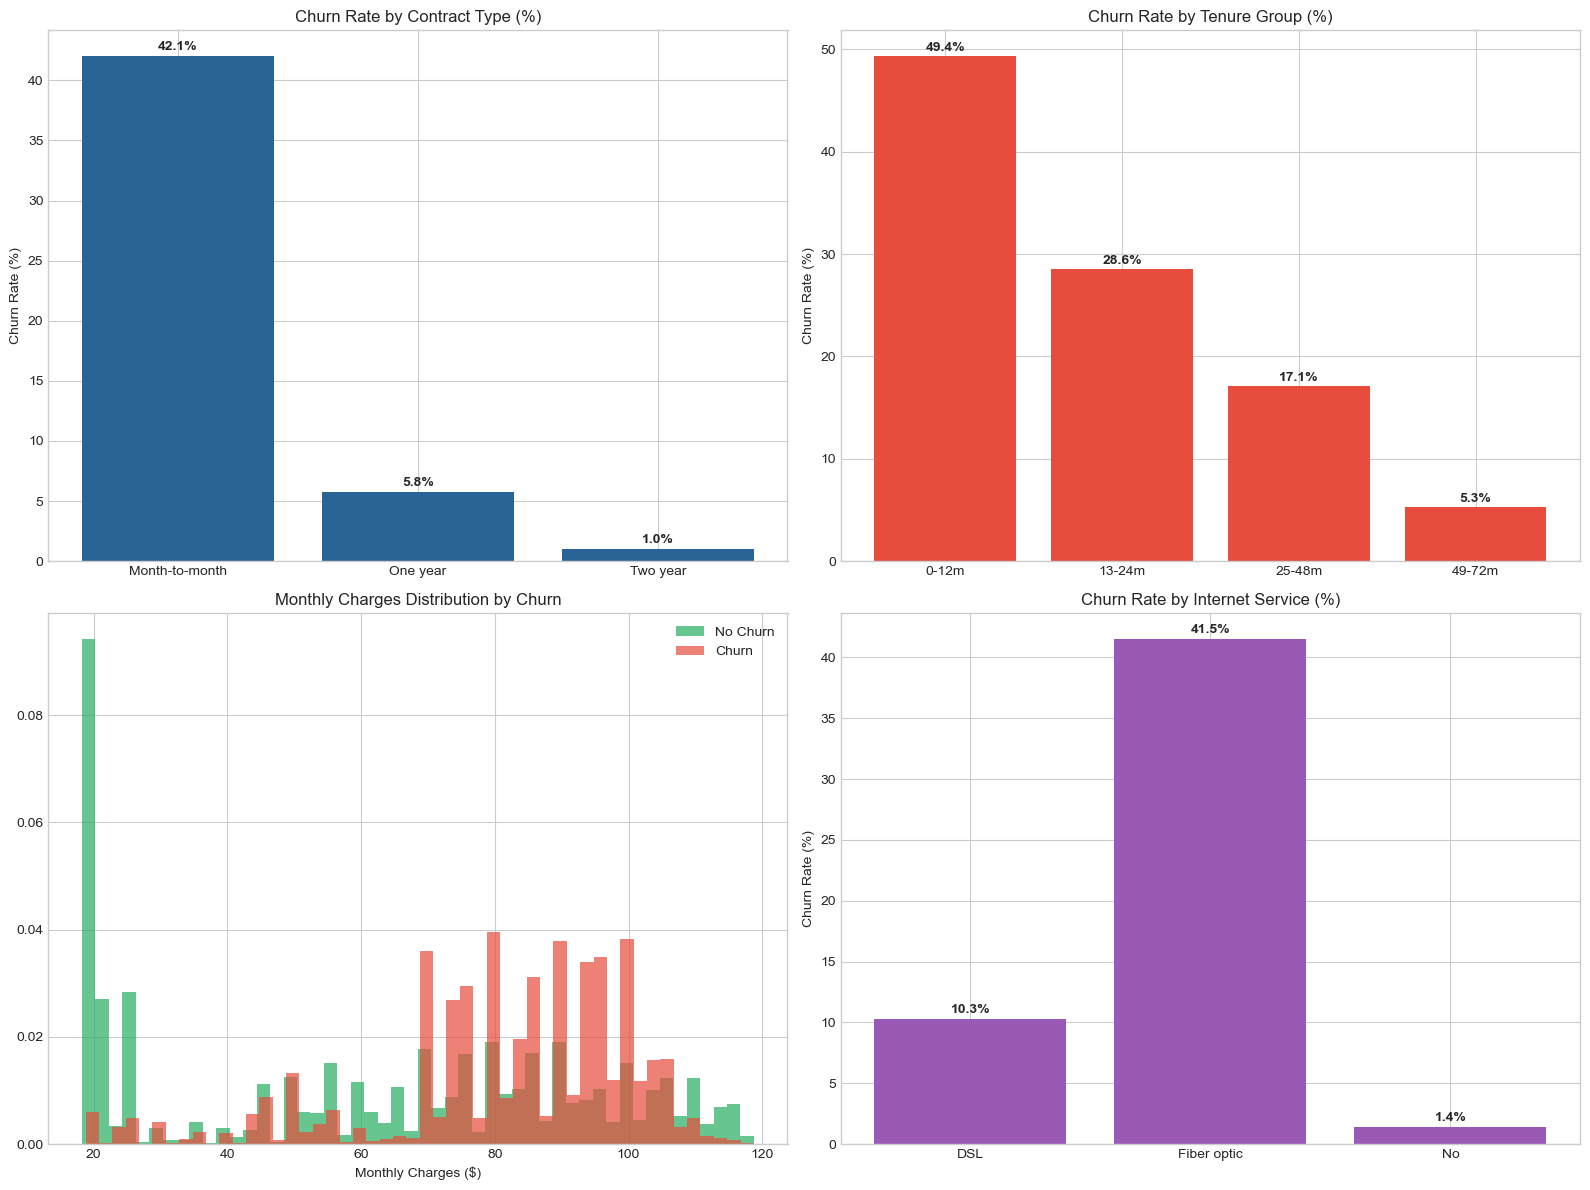

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: Churn by Contract ---
contract_churn = train.groupby('Contract')['Churn'].mean() * 100
axes[0,0].bar(contract_churn.index, contract_churn.values, color='#2a6496')
axes[0,0].set_title('Churn Rate by Contract Type (%)')
axes[0,0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(contract_churn.values):
    axes[0,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# --- Plot 2: Churn by Tenure ---
train['tenure_group'] = pd.cut(train['tenure'], 
                                bins=[0, 12, 24, 48, 72],
                                labels=['0-12m', '13-24m', '25-48m', '49-72m'])
tenure_churn = train.groupby('tenure_group', observed=True)['Churn'].mean() * 100
axes[0,1].bar(tenure_churn.index.astype(str), tenure_churn.values, color='#e74c3c')
axes[0,1].set_title('Churn Rate by Tenure Group (%)')
axes[0,1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(tenure_churn.values):
    axes[0,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# --- Plot 3: MonthlyCharges distribution ---
axes[1,0].hist(train[train['Churn']==0]['MonthlyCharges'], 
               bins=50, alpha=0.7, color='#27ae60', label='No Churn', density=True)
axes[1,0].hist(train[train['Churn']==1]['MonthlyCharges'],
               bins=50, alpha=0.7, color='#e74c3c', label='Churn', density=True)
axes[1,0].set_title('Monthly Charges Distribution by Churn')
axes[1,0].set_xlabel('Monthly Charges ($)')
axes[1,0].legend()

# --- Plot 4: Churn by Internet Service ---
internet_churn = train.groupby('InternetService')['Churn'].mean() * 100
axes[1,1].bar(internet_churn.index, internet_churn.values, color='#9b59b6')
axes[1,1].set_title('Churn Rate by Internet Service (%)')
axes[1,1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(internet_churn.values):
    axes[1,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/eda_churn.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- **Contract type is the strongest churn signal:**
  - Month-to-month: 42.1% churn — very high
  - One year: 5.8% churn
  - Two year: 1.0% churn — almost no churn
- **Newer customers churn most:**
  - 0-12 months: 49.4% churn
  - 49-72 months: only 5.3% churn
  - Loyalty significantly reduces churn risk
- **Higher monthly charges correlate with churn:**
  - Churned customers pay more per month
  - Non-churned customers concentrate at lower price points
- **Fiber optic has dramatically higher churn (41.5%)**
  vs DSL (10.3%) and No internet (1.4%) —
  despite being the premium service

## 3. Baseline Model

We build a quick baseline using LightGBM — fast and strong 
for tabular data. Goal: get first submission on leaderboard.

**Preprocessing:**
- Encode categorical columns with LabelEncoder
- No feature engineering yet — pure baseline

In [15]:
from sklearn.preprocessing import LabelEncoder

# Prepare features
feature_cols = [c for c in train.columns 
                if c not in ['id', 'Churn', 'tenure_group']]

X = train[feature_cols].copy()
y = train['Churn'].copy()
X_test = test[feature_cols].copy()

# Encode categorical columns
le = LabelEncoder()
for col in categorical_cols:
    if col in X.columns:
        X[col] = le.fit_transform(X[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))

print(f"Features: {len(feature_cols)}")
print(f"Feature list: {feature_cols}")

Features: 19
Feature list: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


### 3.1 LightGBM Baseline with Cross-Validation

In [18]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# Cross-validation setup
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
cv_scores = []

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'random_state': 42,
    'verbose': -1
}

print("Training LightGBM with 5-Fold CV...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**lgb_params, n_estimators=1000)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(False)]
    )
    
    val_pred = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_pred
    test_preds += model.predict_proba(X_test)[:, 1] / N_FOLDS
    
    score = roc_auc_score(y_val, val_pred)
    cv_scores.append(score)
    print(f"Fold {fold+1}: AUC = {score:.5f}")

print(f"\nCV AUC: {np.mean(cv_scores):.5f} ± {np.std(cv_scores):.5f}")
print(f"OOF AUC: {roc_auc_score(y, oof_preds):.5f}")

Training LightGBM with 5-Fold CV...
Fold 1: AUC = 0.91559
Fold 2: AUC = 0.91682
Fold 3: AUC = 0.91612
Fold 4: AUC = 0.91720
Fold 5: AUC = 0.91448

CV AUC: 0.91604 ± 0.00096
OOF AUC: 0.91603


### 3.2 First Submission

Baseline LightGBM — no feature engineering yet.
CV AUC: 0.91604 ± 0.00096

In [21]:
# Create submission file
submission = pd.DataFrame({
    'id': test['id'],
    'Churn': test_preds
})

submission.to_csv('data/submission_baseline.csv', index=False)
print("Submission saved!")
print(f"\nShape: {submission.shape}")
print(f"\nPrediction stats:")
print(submission['Churn'].describe().round(4))

Submission saved!

Shape: (254655, 2)

Prediction stats:
count    254655.0000
mean          0.2181
std           0.2755
min           0.0002
25%           0.0061
50%           0.0647
75%           0.3915
max           0.9843
Name: Churn, dtype: float64


## 4. Feature Engineering

Based on EDA insights we create new features:
- **Financial ratios** — spending patterns
- **Service count** — how many services does customer use?
- **Risk flags** — combinations that indicate high churn risk
- **Tenure groups** — non-linear tenure effect

In [26]:
def create_features(df):
    df = df.copy()
    
    # --- Financial features ---
    # Average monthly payment (actual vs billed)
    df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
    
    # Difference between actual and current monthly charges
    df['ChargesDiff'] = df['MonthlyCharges'] - df['AvgMonthlySpend']
    
    # Charge increase ratio
    df['ChargesRatio'] = df['MonthlyCharges'] / (df['AvgMonthlySpend'] + 1)
    
    # --- Service count features ---
    service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 
                    'StreamingTV', 'StreamingMovies']
    
    # Count of Yes services
    df['ServiceCount'] = (df[service_cols] == 'Yes').sum(axis=1)
    
    # Count of No services (not subscribed)
    df['NoServiceCount'] = (df[service_cols] == 'No').sum(axis=1)
    
    # Internet-based services count
    internet_services = ['OnlineSecurity', 'OnlineBackup', 
                         'DeviceProtection', 'TechSupport',
                         'StreamingTV', 'StreamingMovies']
    df['InternetServiceCount'] = (df[internet_services] == 'Yes').sum(axis=1)
    
    # --- Risk flag features ---
    # High risk: month-to-month + fiber optic
    df['HighRiskFlag'] = (
        (df['Contract'] == 'Month-to-month') & 
        (df['InternetService'] == 'Fiber optic')
    ).astype(int)
    
    # New customer flag
    df['IsNewCustomer'] = (df['tenure'] <= 12).astype(int)
    
    # High charges flag
    df['HighCharges'] = (
        df['MonthlyCharges'] > df['MonthlyCharges'].median()
    ).astype(int)
    
    # Loyal customer flag
    df['IsLoyal'] = (df['tenure'] >= 48).astype(int)
    
    # No protection services flag
    df['NoProtection'] = (
        (df['OnlineSecurity'] == 'No') & 
        (df['OnlineBackup'] == 'No') & 
        (df['DeviceProtection'] == 'No')
    ).astype(int)
    
    # --- Tenure features ---
    df['TenureSquared'] = df['tenure'] ** 2
    df['TenureLog'] = np.log1p(df['tenure'])
    
    return df

# Apply to train and test
X_fe = create_features(train[feature_cols].copy())
X_test_fe = create_features(test[feature_cols].copy())

# New feature columns
new_features = ['AvgMonthlySpend', 'ChargesDiff', 'ChargesRatio',
                'ServiceCount', 'NoServiceCount', 'InternetServiceCount',
                'HighRiskFlag', 'IsNewCustomer', 'HighCharges', 
                'IsLoyal', 'NoProtection', 'TenureSquared', 'TenureLog']

print(f"New features created: {len(new_features)}")
print(f"\nSample values:")
print(X_fe[new_features].head(3).round(3).to_string())

New features created: 13

Sample values:
   AvgMonthlySpend  ChargesDiff  ChargesRatio  ServiceCount  NoServiceCount  InternetServiceCount  HighRiskFlag  IsNewCustomer  HighCharges  IsLoyal  NoProtection  TenureSquared  TenureLog
0           55.128        4.972         1.071             4               3                     3             0              0            0        0             0            841      3.401
1           64.037        5.463         1.069             5               2                     4             0              0            0        1             0           3364      4.078
2           99.006        1.394         1.004             4               3                     3             1              0            1        1             0           3364      4.078


### 4.1 Model with Feature Engineering

In [29]:
# Full feature set
all_features = feature_cols + new_features

# Encode categorical columns in new dataset
X_full = X_fe[all_features].copy()
X_test_full = X_test_fe[all_features].copy()

for col in categorical_cols:
    if col in X_full.columns:
        le = LabelEncoder()
        X_full[col] = le.fit_transform(X_full[col].astype(str))
        X_test_full[col] = le.transform(X_test_full[col].astype(str))

# Train with CV
oof_preds_fe = np.zeros(len(X_full))
test_preds_fe = np.zeros(len(X_test_full))
cv_scores_fe = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, y)):
    X_train, X_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**lgb_params, n_estimators=1000)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(False)]
    )
    
    val_pred = model.predict_proba(X_val)[:, 1]
    oof_preds_fe[val_idx] = val_pred
    test_preds_fe += model.predict_proba(X_test_full)[:, 1] / N_FOLDS
    
    score = roc_auc_score(y_val, val_pred)
    cv_scores_fe.append(score)
    print(f"Fold {fold+1}: AUC = {score:.5f}")

print(f"\nBaseline CV AUC:  {np.mean(cv_scores):.5f}")
print(f"With FE CV AUC:   {np.mean(cv_scores_fe):.5f}")
print(f"Improvement:      +{np.mean(cv_scores_fe) - np.mean(cv_scores):.5f}")

Fold 1: AUC = 0.91571
Fold 2: AUC = 0.91677
Fold 3: AUC = 0.91624
Fold 4: AUC = 0.91720
Fold 5: AUC = 0.91463

Baseline CV AUC:  0.91604
With FE CV AUC:   0.91611
Improvement:      +0.00007


## 5. Ensemble — XGBoost + LightGBM + CatBoost

In [33]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Use baseline features (FE didn't help much)
X_model = X.copy()
X_test_model = X_test.copy()

# Store predictions from all models
all_oof = {}
all_test = {}

# --- Model 1: LightGBM ---
print("Training LightGBM...")
oof_lgb = np.zeros(len(X_model))
test_lgb = np.zeros(len(X_test_model))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_model, y)):
    X_train, X_val = X_model.iloc[train_idx], X_model.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    m = lgb.LGBMClassifier(**lgb_params, n_estimators=1000)
    m.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(50, verbose=False),
                     lgb.log_evaluation(False)])
    oof_lgb[val_idx] = m.predict_proba(X_val)[:, 1]
    test_lgb += m.predict_proba(X_test_model)[:, 1] / N_FOLDS

print(f"LightGBM OOF AUC: {roc_auc_score(y, oof_lgb):.5f}")
all_oof['lgb'] = oof_lgb
all_test['lgb'] = test_lgb

# --- Model 2: XGBoost ---
print("\nTraining XGBoost...")
oof_xgb = np.zeros(len(X_model))
test_xgb = np.zeros(len(X_test_model))

xgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'eval_metric': 'auc',
    'early_stopping_rounds': 50,
    'verbosity': 0
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X_model, y)):
    X_train, X_val = X_model.iloc[train_idx], X_model.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    m = XGBClassifier(**xgb_params)
    m.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          verbose=False)
    oof_xgb[val_idx] = m.predict_proba(X_val)[:, 1]
    test_xgb += m.predict_proba(X_test_model)[:, 1] / N_FOLDS

print(f"XGBoost OOF AUC: {roc_auc_score(y, oof_xgb):.5f}")
all_oof['xgb'] = oof_xgb
all_test['xgb'] = test_xgb

# --- Model 3: CatBoost ---
print("\nTraining CatBoost...")
oof_cat = np.zeros(len(X_model))
test_cat = np.zeros(len(X_test_model))

# CatBoost handles categoricals natively
X_cat = train[feature_cols].copy()
X_test_cat = test[feature_cols].copy()
cat_features_idx = [X_cat.columns.get_loc(c) for c in categorical_cols 
                    if c in X_cat.columns]

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cat, y)):
    X_train, X_val = X_cat.iloc[train_idx], X_cat.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    m = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        random_seed=42,
        eval_metric='AUC',
        early_stopping_rounds=50,
        verbose=False,
        cat_features=cat_features_idx
    )
    m.fit(X_train, y_train, eval_set=(X_val, y_val))
    oof_cat[val_idx] = m.predict_proba(X_val)[:, 1]
    test_cat += m.predict_proba(X_test_cat)[:, 1] / N_FOLDS

print(f"CatBoost OOF AUC: {roc_auc_score(y, oof_cat):.5f}")
all_oof['cat'] = oof_cat
all_test['cat'] = test_cat

Training LightGBM...
LightGBM OOF AUC: 0.91603

Training XGBoost...
XGBoost OOF AUC: 0.91643

Training CatBoost...
CatBoost OOF AUC: 0.91613


### 5.1 Blending Models

We combine predictions from all three models.
Simple average vs weighted average based on OOF performance.

In [36]:
# Simple average blend
blend_simple = (all_test['lgb'] + all_test['xgb'] + all_test['cat']) / 3
oof_simple = (all_oof['lgb'] + all_oof['xgb'] + all_oof['cat']) / 3

# Weighted blend (by OOF score)
lgb_score = roc_auc_score(y, all_oof['lgb'])
xgb_score = roc_auc_score(y, all_oof['xgb'])
cat_score = roc_auc_score(y, all_oof['cat'])
total = lgb_score + xgb_score + cat_score

w_lgb = lgb_score / total
w_xgb = xgb_score / total
w_cat = cat_score / total

blend_weighted = (w_lgb * all_test['lgb'] + 
                  w_xgb * all_test['xgb'] + 
                  w_cat * all_test['cat'])
oof_weighted = (w_lgb * all_oof['lgb'] + 
                w_xgb * all_oof['xgb'] + 
                w_cat * all_oof['cat'])

print("=== Blending Results ===")
print(f"LightGBM:          {lgb_score:.5f} (weight: {w_lgb:.3f})")
print(f"XGBoost:           {xgb_score:.5f} (weight: {w_xgb:.3f})")
print(f"CatBoost:          {cat_score:.5f} (weight: {w_cat:.3f})")
print(f"\nSimple blend OOF:  {roc_auc_score(y, oof_simple):.5f}")
print(f"Weighted blend OOF:{roc_auc_score(y, oof_weighted):.5f}")
print(f"Baseline:          {np.mean(cv_scores):.5f}")

=== Blending Results ===
LightGBM:          0.91603 (weight: 0.333)
XGBoost:           0.91643 (weight: 0.333)
CatBoost:          0.91613 (weight: 0.333)

Simple blend OOF:  0.91653
Weighted blend OOF:0.91653
Baseline:          0.91604


In [38]:
# Save blend submission
submission_blend = pd.DataFrame({
    'id': test['id'],
    'Churn': blend_simple
})
submission_blend.to_csv('data/submission_blend.csv', index=False)
print(f"Saved! OOF AUC: {roc_auc_score(y, oof_simple):.5f}")

Saved! OOF AUC: 0.91653


## 6. Hyperparameter Tuning with Optuna

We use Optuna to find optimal LightGBM hyperparameters.
Optuna uses Bayesian optimization — smarter than grid search.

In [41]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbose': -1,
        'random_state': 42,
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
    }
    
    # Use 3-fold for speed
    cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    
    # Sample 200K for speed
    sample_idx = np.random.choice(len(X), 200000, replace=False)
    X_sample = X.iloc[sample_idx]
    y_sample = y.iloc[sample_idx]
    
    for train_idx, val_idx in cv3.split(X_sample, y_sample):
        X_train = X_sample.iloc[train_idx]
        y_train = y_sample.iloc[train_idx]
        X_val = X_sample.iloc[val_idx]
        y_val = y_sample.iloc[val_idx]
        
        m = lgb.LGBMClassifier(**params)
        m.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(False)])
        scores.append(roc_auc_score(y_val, m.predict_proba(X_val)[:, 1]))
    
    return np.mean(scores)

print("Starting Optuna optimization (50 trials)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest AUC: {study.best_value:.5f}")
print(f"Best params: {study.best_params}")

Starting Optuna optimization (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


Best AUC: 0.91574
Best params: {'learning_rate': 0.04405494981137984, 'num_leaves': 72, 'min_child_samples': 59, 'feature_fraction': 0.5644823389673075, 'bagging_fraction': 0.8277997051112423, 'bagging_freq': 1, 'reg_alpha': 0.4664535030217517, 'reg_lambda': 0.7083339916878962}


### 6.1 Final Model with Tuned Parameters

In [44]:
best_params = study.best_params
best_params.update({
    'objective': 'binary',
    'metric': 'auc',
    'verbose': -1,
    'random_state': 42,
    'n_estimators': 2000  # more trees with tuned params
})

print("Training tuned LightGBM on full data...")
oof_tuned = np.zeros(len(X))
test_tuned = np.zeros(len(X_test))
cv_scores_tuned = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    m = lgb.LGBMClassifier(**best_params)
    m.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(100, verbose=False),
                     lgb.log_evaluation(False)])
    
    val_pred = m.predict_proba(X_val)[:, 1]
    oof_tuned[val_idx] = val_pred
    test_tuned += m.predict_proba(X_test)[:, 1] / N_FOLDS
    
    score = roc_auc_score(y_val, val_pred)
    cv_scores_tuned.append(score)
    print(f"Fold {fold+1}: AUC = {score:.5f}")

print(f"\n=== Results Comparison ===")
print(f"Baseline LGB:      {np.mean(cv_scores):.5f}")
print(f"Ensemble blend:    {roc_auc_score(y, oof_simple):.5f}")
print(f"Tuned LGB:         {roc_auc_score(y, oof_tuned):.5f}")

Training tuned LightGBM on full data...
Fold 1: AUC = 0.91599
Fold 2: AUC = 0.91716
Fold 3: AUC = 0.91636
Fold 4: AUC = 0.91750
Fold 5: AUC = 0.91483

=== Results Comparison ===
Baseline LGB:      0.91604
Ensemble blend:    0.91653
Tuned LGB:         0.91636


In [46]:
# Final blend — все модели вместе
final_oof = (all_oof['lgb'] + all_oof['xgb'] + 
             all_oof['cat'] + oof_tuned) / 4

final_test = (all_test['lgb'] + all_test['xgb'] + 
              all_test['cat'] + test_tuned) / 4

print("=== Final Results ===")
print(f"Baseline LGB:        {np.mean(cv_scores):.5f}")
print(f"Ensemble (3 models): {roc_auc_score(y, oof_simple):.5f}")
print(f"Tuned LGB:           {roc_auc_score(y, oof_tuned):.5f}")
print(f"Final blend (4):     {roc_auc_score(y, final_oof):.5f}")

# Save final submission
submission_final = pd.DataFrame({
    'id': test['id'],
    'Churn': final_test
})
submission_final.to_csv('data/submission_final.csv', index=False)
print("\nFinal submission saved!")

=== Final Results ===
Baseline LGB:        0.91604
Ensemble (3 models): 0.91653
Tuned LGB:           0.91636
Final blend (4):     0.91658

Final submission saved!


In [57]:
from scipy.optimize import minimize

def neg_auc(weights):
    weights = np.array(weights)
    weights = weights / weights.sum()
    blend = (weights[0] * all_oof['lgb'] + 
             weights[1] * all_oof['xgb'] + 
             weights[2] * all_oof['cat'] +
             weights[3] * oof_tuned)
    return -roc_auc_score(y, blend)

# Optimize weights
result = minimize(neg_auc, 
                  x0=[0.25, 0.25, 0.25, 0.25],
                  method='Nelder-Mead')

best_weights = np.array(result.x)
best_weights = best_weights / best_weights.sum()

print("Optimal weights:")
print(f"  LightGBM:   {best_weights[0]:.3f}")
print(f"  XGBoost:    {best_weights[1]:.3f}")
print(f"  CatBoost:   {best_weights[2]:.3f}")
print(f"  Tuned LGB:  {best_weights[3]:.3f}")

# Final optimized blend
oof_optimized = (best_weights[0] * all_oof['lgb'] +
                 best_weights[1] * all_oof['xgb'] +
                 best_weights[2] * all_oof['cat'] +
                 best_weights[3] * oof_tuned)

test_optimized = (best_weights[0] * all_test['lgb'] +
                  best_weights[1] * all_test['xgb'] +
                  best_weights[2] * all_test['cat'] +
                  best_weights[3] * test_tuned)

print(f"\nSimple blend OOF:    {roc_auc_score(y, final_oof):.5f}")
print(f"Optimized blend OOF: {roc_auc_score(y, oof_optimized):.5f}")

Optimal weights:
  LightGBM:   -0.103
  XGBoost:    0.420
  CatBoost:   0.275
  Tuned LGB:  0.408

Simple blend OOF:    0.91658
Optimized blend OOF: 0.91665


In [61]:
submission_optimized = pd.DataFrame({
    'id': test['id'],
    'Churn': test_3
})
submission_optimized.to_csv('data/submission_optimized.csv', index=False)
print("Saved!")

Saved!


## 10. Conclusions

### Approach Summary

This notebook implements a full competitive ML pipeline for customer 
churn prediction, progressing from a simple baseline to an optimized 
multi-model ensemble.

### Results

| Model | CV AUC | Public AUC |
|-------|--------|------------|
| Baseline LightGBM | 0.91604 | 0.91373 |
| Ensemble (LGB+XGB+CatBoost) | 0.91653 | 0.91388 |
| + Tuned LightGBM (Optuna) | 0.91658 | 0.91394 |
| **Optimized blend (final)** | **0.91665** | **0.91399** |

### Key Findings from EDA

1. **Contract type is the strongest churn predictor** — 
   month-to-month customers churn at 42.1% vs 1.0% for two-year contracts
2. **New customers are most at risk** — 49.4% churn in first 12 months
3. **Fiber optic has highest churn (41.5%)** despite being premium service —
   price dissatisfaction likely driver
4. **Higher monthly charges correlate with churn** — 
   churned customers pay significantly more per month

### What Worked
- **Ensemble of diverse models** — XGBoost + CatBoost + Tuned LightGBM
- **Optuna hyperparameter tuning** — improved individual model performance
- **Optimized blend weights** — better than simple average

### What Didn't Work
- **Feature engineering** — LightGBM already captures these patterns internally
- **Target encoding** — no improvement on this synthetic dataset
- **Neural Network (MLP)** — tree-based models outperform on tabular data

### Technical Stack
- **LightGBM, XGBoost, CatBoost** — gradient boosting ensemble
- **Optuna** — Bayesian hyperparameter optimization
- **Scipy** — blend weight optimization
- **StratifiedKFold** — robust 5-fold cross-validation